In [109]:
import os
from PIL import Image
import torch
from model import Unet
import torch.utils.data as data
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.v2 as tfs
import torch.utils.data as data
from tqdm import tqdm

In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [111]:
def resize(x):
    if x.dim() == 3:
        x = x.unsqueeze(0)
    x = F.interpolate(x, size=(576, 576), mode='bilinear', align_corners=False)
    return x.squeeze()


class DriveDataset(data.Dataset):
    def __init__(self, path, train=True):
        self.path = os.path.join(path, 'train' if train else 'test')
        self.image_dir = os.path.join(self.path, 'image')
        self.mask_dir = os.path.join(self.path, 'mask')
        self.transform = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32, scale=True)])
        self.resize = resize
        self.image_files = os.listdir(self.image_dir)
        self.length = len(self.image_files)
    
    def __getitem__(self, item):
        image_name = self.image_files[item]
        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, image_name)
        
        image = self.resize(self.transform(Image.open(image_path)).to(device))
        mask = self.resize(self.transform(Image.open(mask_path)).to(device))
        return (image, mask)
    
    def __len__(self):
        return self.length


In [112]:
d_train, d_val = data.random_split(DriveDataset('C:\\Users\\aponc\\CV\\DRIVE\\Data', train=True), [0.7, 0.3])
d_test = DriveDataset('C:/Users/aponc/CV/DRIVE/Data', train=False)

train_data = data.DataLoader(d_train, batch_size=8, shuffle=True)
test_data = data.DataLoader(d_test, batch_size=len(d_test), shuffle=False)
val_data = data.DataLoader(d_val, batch_size=8, shuffle=False)

In [113]:
class SoftDiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        num = targets.size(0)
        probs = F.sigmoid(logits)
        m1 = probs.view(num, -1)
        m2 = targets.view(num, -1)
        intersection = m1 * m2

        score = 2 * (intersection.sum(1) + self.smooth) / (m1.sum(1) + m2.sum(1) + self.smooth)
        score = 1 - score.sum() / num
        return score

In [125]:
model = Unet().to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)
loss_1 = nn.BCEWithLogitsLoss()
loss_2 = SoftDiceLoss()
n_epochs = 6

In [126]:
loss_lst_train = []
loss_lst_val = []
for e in range(n_epochs):
    model.train()
    loss_mean = 0
    lm_count = 0

    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict = model(x_train).squeeze()
        loss = loss_1(predict, y_train) + loss_2(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

        train_tqdm.set_description(f'Epoch [{e+1}/{n_epochs}], mean loss: {loss_mean:.3f}')

    model.eval()
    Q_val = 0
    val_count = 0
    for x_val, y_val in val_data:
        with torch.no_grad():
            predict = model(x_val).squeeze()
            loss = loss_1(predict, y_val) + loss_2(predict, y_val)
            Q_val += loss.item()
            val_count += 1

    Q_val /= val_count
    loss_lst_train.append(loss_mean)
    loss_lst_val.append(Q_val)

    print(f' | loss_mean = {loss_mean:.3f}, Q_val = {Q_val:.3f}')

Epoch [1/6], mean loss: 1.451: 100%|██████████| 7/7 [00:08<00:00,  1.20s/it]


 | loss_mean = 1.451, Q_val = 1.520


Epoch [2/6], mean loss: 1.253: 100%|██████████| 7/7 [00:08<00:00,  1.19s/it]


 | loss_mean = 1.253, Q_val = 1.445


Epoch [3/6], mean loss: 1.173: 100%|██████████| 7/7 [00:08<00:00,  1.17s/it]


...

 | loss_mean = 1.121, Q_val = 1.236


Epoch [5/6], mean loss: 1.077: 100%|██████████| 7/7 [00:07<00:00,  1.14s/it]


 | loss_mean = 1.077, Q_val = 1.154


Epoch [6/6], mean loss: 1.035: 100%|██████████| 7/7 [00:08<00:00,  1.22s/it]


 | loss_mean = 1.035, Q_val = 1.085


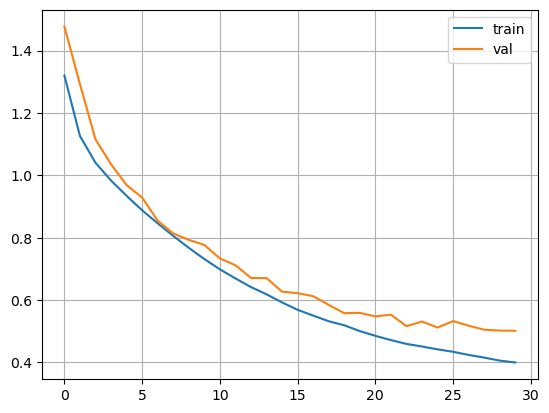

In [123]:
plt.plot(loss_lst_train, label='train')
plt.plot(loss_lst_val, label='val')
plt.legend()
plt.grid()

In [127]:
with torch.no_grad():
    for x_test, y_test in test_data:
        predict = model(x_test).squeeze()
        predict = torch.where(predict >= 0.5, torch.tensor(1.0), torch.tensor(0.0))
        score = (predict == y_test).float().mean()
        
print(score.item())

0.8595525622367859


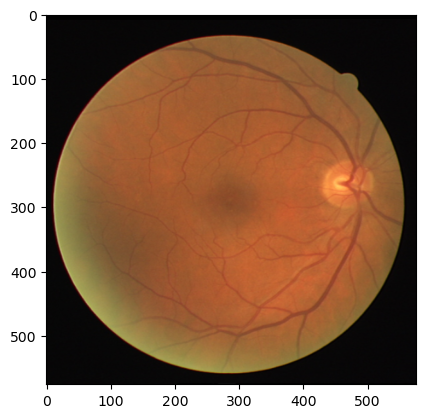

In [134]:
test_data = data.DataLoader(d_test, batch_size=1, shuffle=True)
image, mask = next(iter(test_data))
predict = model(image).squeeze()
image = image.cpu().squeeze().numpy()
image = image.transpose(1, 2, 0)
x = nn.functional.sigmoid(predict)
x = x.cpu().detach().numpy() * 255
plt.imshow(image)

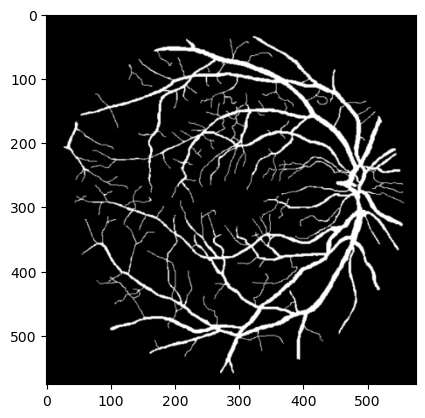

In [137]:
plt.imshow(mask.cpu().squeeze(), cmap='grey')

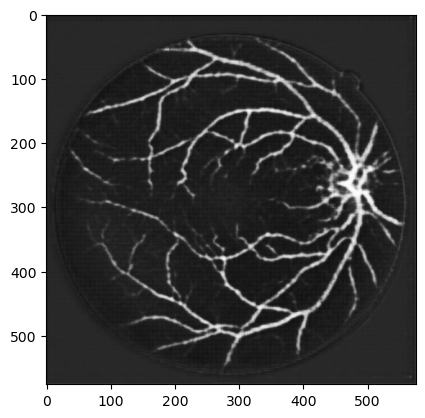

In [136]:
plt.imshow(x, cmap='grey')